# Transaction Data Analysis

This notebook walks through the transaction generator, generates the full pipeline (customers → accounts → transactions), and analyzes the output to verify the data looks realistic for UAT.

**What we cover:**
1. Generate the full dataset
2. Inspect sample transactions by account type
3. Transaction volume by account type
4. Transaction code (type) breakdown
5. Debit vs. credit split
6. Amount distributions
7. Merchant category breakdown
8. Transaction volume over time
9. Running balance trends for sample accounts
10. Export transaction data

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from datetime import date

from src.generators.customer import generate_customers
from src.generators.accounts import generate_accounts
from src.generators.transactions import generate_transactions
from src.models.account import AccountType
from src.models.transaction import TransactionType

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Setup complete.')

Setup complete.


## 1. Generate the Full Dataset

Transactions sit at the bottom of the dependency chain — they require accounts, which require customers. We generate all three using the same seed so every notebook in this series produces a consistent, cross-referenceable dataset.

In [2]:
SEED = 42

customers    = generate_customers(count=250, seed=SEED)
accounts     = generate_accounts(customers=customers, total_accounts=450, seed=SEED)
transactions = generate_transactions(accounts=accounts, total_transactions=7500, seed=SEED)

print(f'Customers    : {len(customers):,}')
print(f'Accounts     : {len(accounts):,}')
print(f'Transactions : {len(transactions):,}')

Customers    : 250
Accounts     : 450
Transactions : 7,500


## 2. Inspect Sample Transactions

One sample per account type so we can verify the fields look correct — especially that CDs only show INTEREST_POSTING, and merchant fields are null where they should be.

In [3]:
# Build a quick lookup of account_id → account_type for filtering
acct_type_map = {a.account_id: a.account_type for a in accounts}

def print_txn(t):
    print(f'  Transaction ID   : {t.transaction_id}')
    print(f'  Account ID       : {t.account_id}')
    print(f'  Customer ID      : {t.customer_id}')
    print(f'  Transaction Date : {t.transaction_date}')
    print(f'  Post Date        : {t.post_date}')
    print(f'  Type / Code      : {t.transaction_type} / {t.transaction_code}')
    print(f'  Amount           : ${t.amount:,.2f}')
    print(f'  Running Balance  : ${t.running_balance:,.2f}')
    print(f'  Description      : {t.description}')
    print(f'  Merchant         : {t.merchant_name or "N/A"} ({t.merchant_category or "N/A"})')
    print(f'  Check Number     : {t.check_number or "N/A"}')

for acct_type in AccountType:
    sample = next(t for t in transactions if acct_type_map[t.account_id] == acct_type)
    print(f'--- {acct_type} ---')
    print_txn(sample)
    print()

--- Checking ---
  Transaction ID   : TXN-0000001
  Account ID       : ACT-000001
  Customer ID      : CIF-000001
  Transaction Date : 2025-05-21
  Post Date        : 2025-05-23
  Type / Code      : Debit / BILL_PAY
  Amount           : $1,470.28
  Running Balance  : $2,391.87
  Description      : BILL PAY - Property Management LLC
  Merchant         : Property Management LLC (Rent/Mortgage)
  Check Number     : N/A

--- Savings ---
  Transaction ID   : TXN-0003599
  Account ID       : ACT-000251
  Customer ID      : CIF-000109
  Transaction Date : 2025-05-29
  Post Date        : 2025-05-31
  Type / Code      : Credit / ACH_CREDIT
  Amount           : $700.65
  Running Balance  : $26,561.79
  Description      : ACH CREDIT
  Merchant         : N/A (N/A)
  Check Number     : N/A

--- CD ---
  Transaction ID   : TXN-0003744
  Account ID       : ACT-000260
  Customer ID      : CIF-000246
  Transaction Date : 2025-06-22
  Post Date        : 2025-06-24
  Type / Code      : Credit / INTEREST_

## 3. Build a DataFrame

In [4]:
records = []
for t in transactions:
    records.append({
        'transaction_id':   t.transaction_id,
        'account_id':       t.account_id,
        'customer_id':      t.customer_id,
        'account_type':     acct_type_map[t.account_id],
        'transaction_date': pd.to_datetime(t.transaction_date),
        'post_date':        pd.to_datetime(t.post_date),
        'transaction_type': t.transaction_type,
        'transaction_code': t.transaction_code,
        'amount':           t.amount,
        'running_balance':  t.running_balance,
        'description':      t.description,
        'merchant_name':    t.merchant_name,
        'merchant_category': t.merchant_category,
        'check_number':     t.check_number,
    })

df = pd.DataFrame(records)
df['month'] = df['transaction_date'].dt.to_period('M')

print(f'DataFrame shape: {df.shape}')
df.head()

DataFrame shape: (7500, 15)


,transaction_id,account_id,customer_id,account_type,transaction_date,post_date,transaction_type,transaction_code,amount,running_balance,description,merchant_name,merchant_category,check_number,month
0,TXN-0000001,ACT-000001,CIF-000001,Checking,2025-05-21,2025-05-23,Debit,BILL_PAY,1470.28,2391.87,BILL PAY - Property Management LLC,Property Management LLC,Rent/Mortgage,NaN,2025-05
1,TXN-0000002,ACT-000001,CIF-000001,Checking,2025-06-03,2025-06-05,Credit,MOBILE_DEPOSIT,750.59,3142.46,MOBILE CHECK DEPOSIT,NaN,NaN,NaN,2025-06
2,TXN-0000003,ACT-000001,CIF-000001,Checking,2025-06-17,2025-06-19,Debit,ACH_DEBIT,1098.77,2043.69,ACH DEBIT,NaN,NaN,NaN,2025-06
3,TXN-0000004,ACT-000001,CIF-000001,Checking,2025-06-21,2025-06-21,Credit,DIRECT_DEPOSIT,6801.90,8845.59,PAYROLL DIRECT DEPOSIT,NaN,NaN,NaN,2025-06
4,TXN-0000005,ACT-000001,CIF-000001,Checking,2025-06-23,2025-06-24,Debit,PURCHASE,57.49,8788.10,POS PURCHASE - Prime Fuel,Prime Fuel,Gas Stations,NaN,2025-06


## 4. Transaction Volume by Account Type

Checking should dominate — it gets 70% of the non-CD budget. Savings gets 30%. CDs get exactly 1 interest posting per month per account.

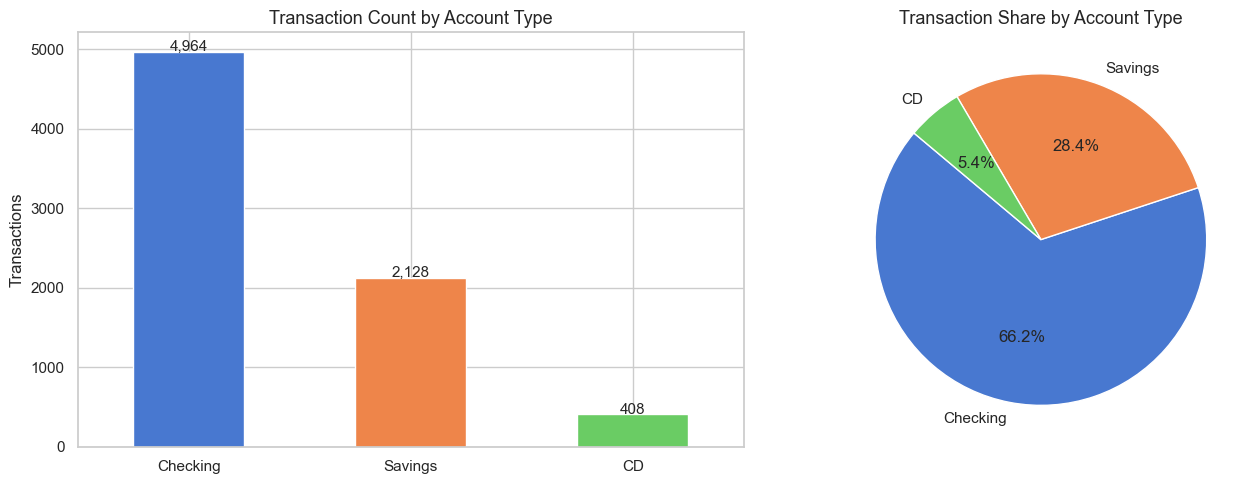

In [5]:
type_counts = df['account_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', 3), edgecolor='white')
axes[0].set_title('Transaction Count by Account Type', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Transactions')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('muted', 3),
)
axes[1].set_title('Transaction Share by Account Type', fontsize=13)

plt.tight_layout()
plt.show()

## 5. Transaction Code Breakdown

Within Checking, PURCHASE should be the most frequent code (weight 30.0 out of ~91 total). DIRECT_DEPOSIT and ATM_WITHDRAWAL should be next. CDs should show only INTEREST_POSTING.

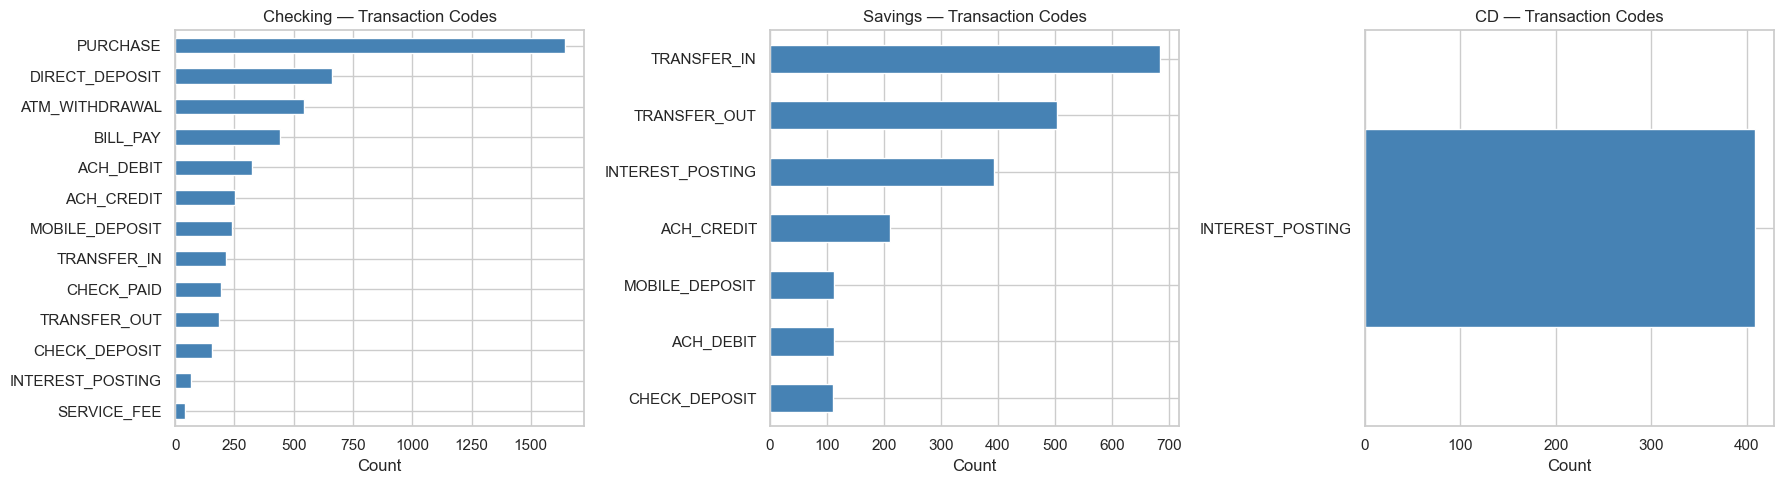

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, acct_type in zip(axes, ['Checking', 'Savings', 'CD']):
    subset = df[df['account_type'] == acct_type]['transaction_code'].value_counts()
    subset.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{acct_type} — Transaction Codes', fontsize=12)
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Debit vs. Credit Split

Across the full dataset, debits should outnumber credits — there are more debit codes than credit codes in the Checking mix, and purchases are the dominant code.

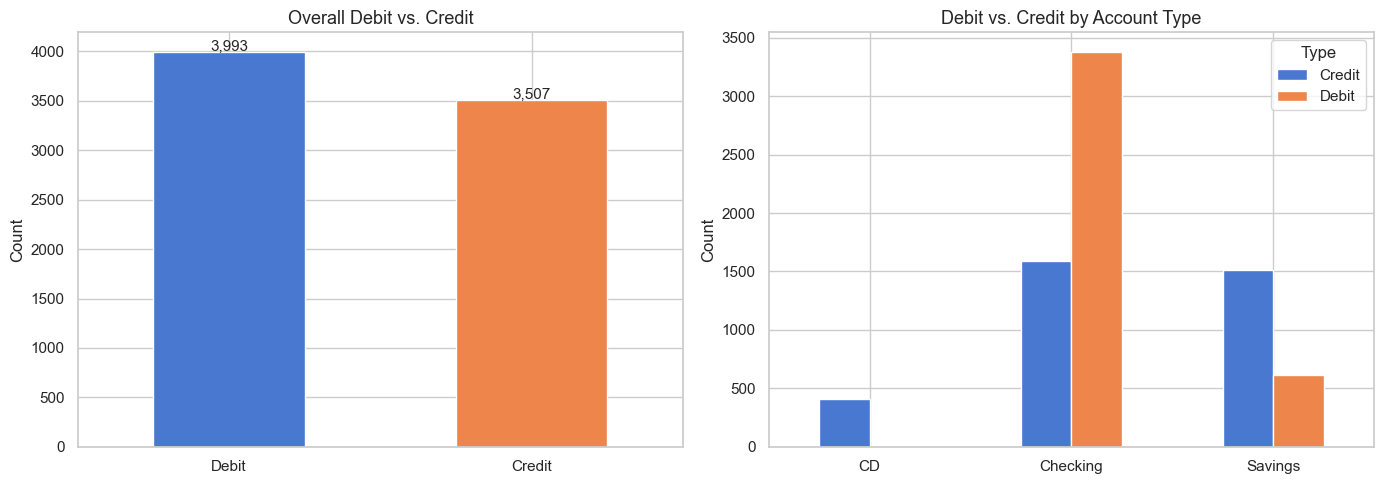

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall split
overall = df['transaction_type'].value_counts()
overall.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', 2), edgecolor='white')
axes[0].set_title('Overall Debit vs. Credit', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(overall.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=11)

# Split by account type
split = df.groupby(['account_type', 'transaction_type']).size().unstack(fill_value=0)
split.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', 2), edgecolor='white')
axes[1].set_title('Debit vs. Credit by Account Type', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type')

plt.tight_layout()
plt.show()

## 7. Amount Distributions

Amounts use a log-normal distribution — small transactions are more common than large ones. This mirrors real-world spending patterns. The chart should show a right-skewed curve.

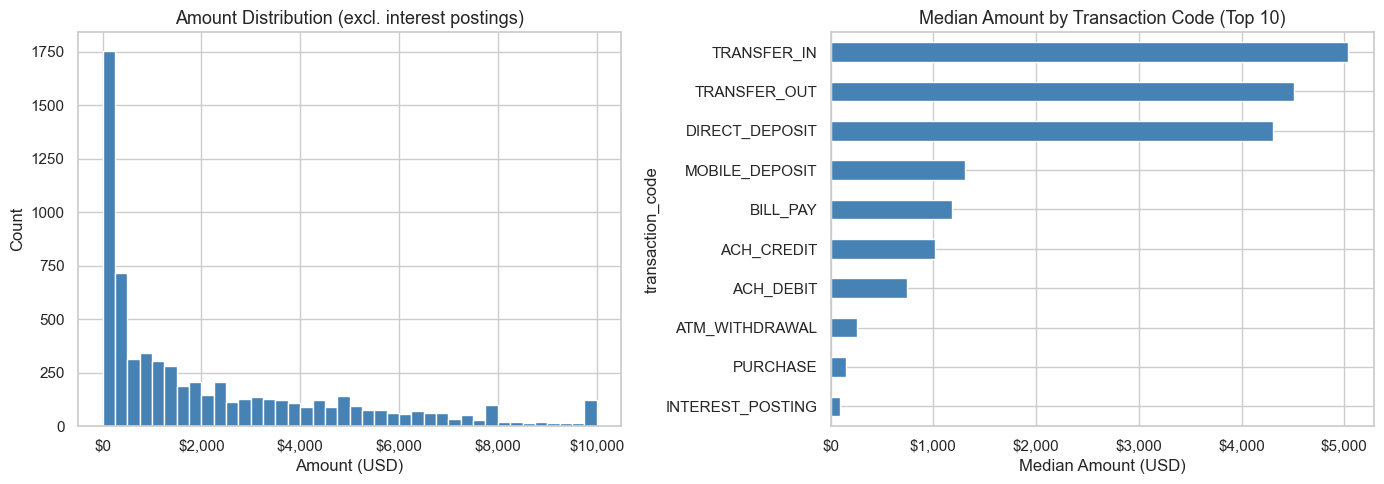

,min,median,max,mean
transaction_type,,,,
Credit,$0.01,"$2,000.00","$10,000.00","$2,770.97"
Debit,$1.00,$300.00,"$10,000.00","$1,273.87"


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall amount distribution (excluding interest postings — they're tiny)
non_interest = df[df['transaction_code'] != 'INTEREST_POSTING']['amount']
axes[0].hist(non_interest, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Amount Distribution (excl. interest postings)', fontsize=13)
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Median amount by transaction code (top 10 codes)
top_codes = df['transaction_code'].value_counts().head(10).index
median_amounts = df[df['transaction_code'].isin(top_codes)] \
    .groupby('transaction_code')['amount'].median().sort_values(ascending=True)
median_amounts.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Median Amount by Transaction Code (Top 10)', fontsize=13)
axes[1].set_xlabel('Median Amount (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Summary stats by transaction type
df.groupby('transaction_type')['amount'].agg(['min', 'median', 'max', 'mean']) \
  .map(lambda x: f'${x:,.2f}')

## 8. Merchant Category Breakdown

Only PURCHASE, ATM_WITHDRAWAL, and BILL_PAY transactions have merchant categories. This chart shows which categories appear most frequently across the purchase mix.

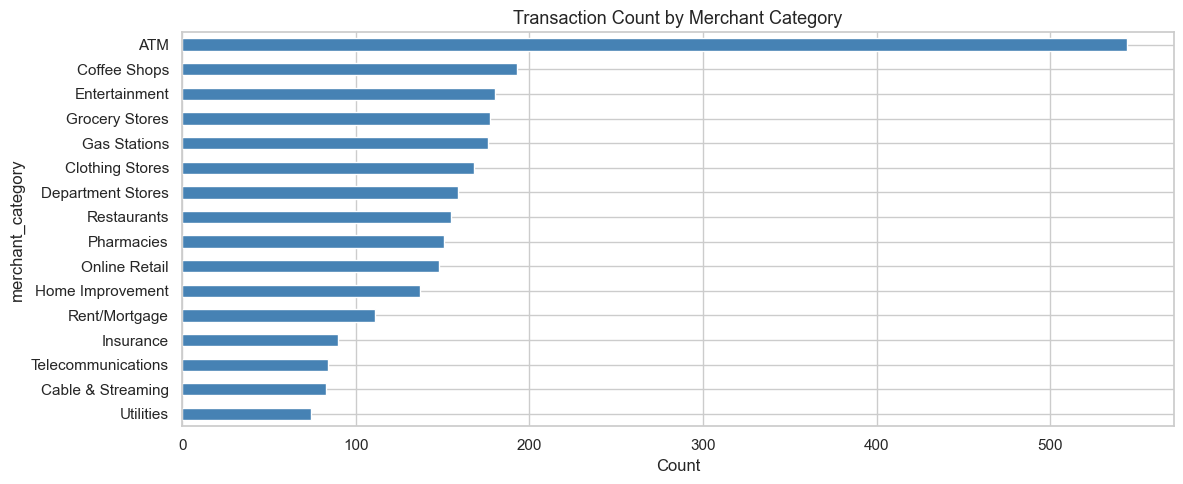

Transactions with a merchant category : 2,630
Transactions without (internal/fees)  : 4,870


In [9]:
merchant_counts = df['merchant_category'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
merchant_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Transaction Count by Merchant Category', fontsize=13)
ax.set_xlabel('Count')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f'Transactions with a merchant category : {merchant_counts.sum():,}')
print(f'Transactions without (internal/fees)  : {df["merchant_category"].isna().sum():,}')

## 9. Transaction Volume Over Time

Transaction dates are spread randomly across the 12-month history window. The monthly volume should be roughly flat with some natural variance.

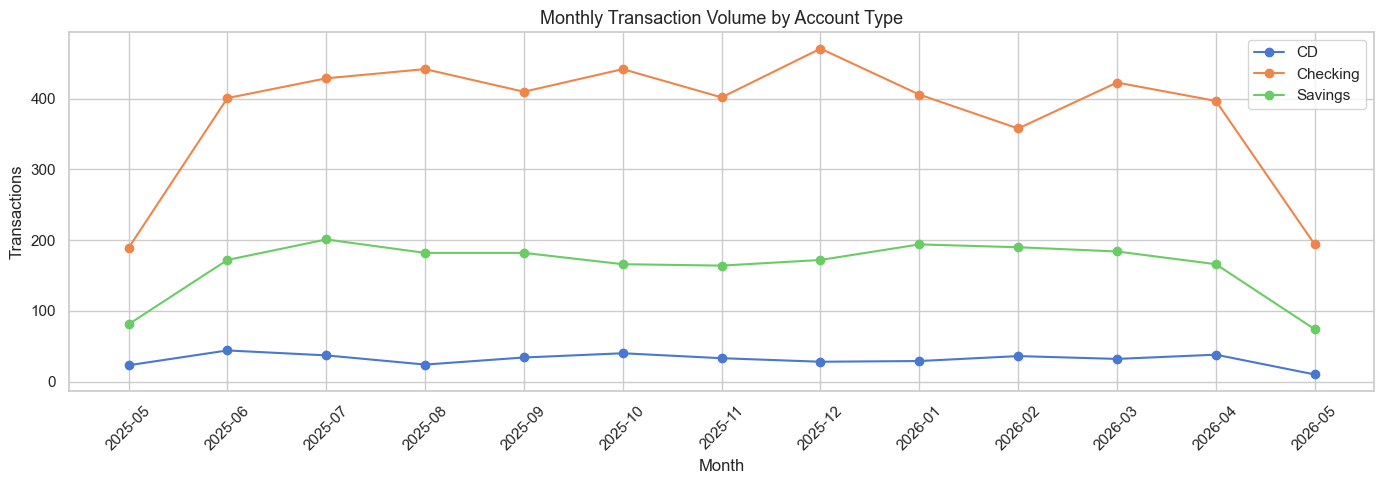

In [10]:
monthly = df.groupby(['month', 'account_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(monthly.columns, sns.color_palette('muted', 3)):
    ax.plot(monthly.index.astype(str), monthly[col], marker='o', label=col, color=color)

ax.set_title('Monthly Transaction Volume by Account Type', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Transactions')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## 10. Running Balance Trends — Sample Checking Accounts

Pick a handful of Checking accounts and plot their running balance over time. This is the most visual "does it look like real banking activity" check — we should see balances fluctuating with payroll credits boosting and purchases/bills drawing them down.

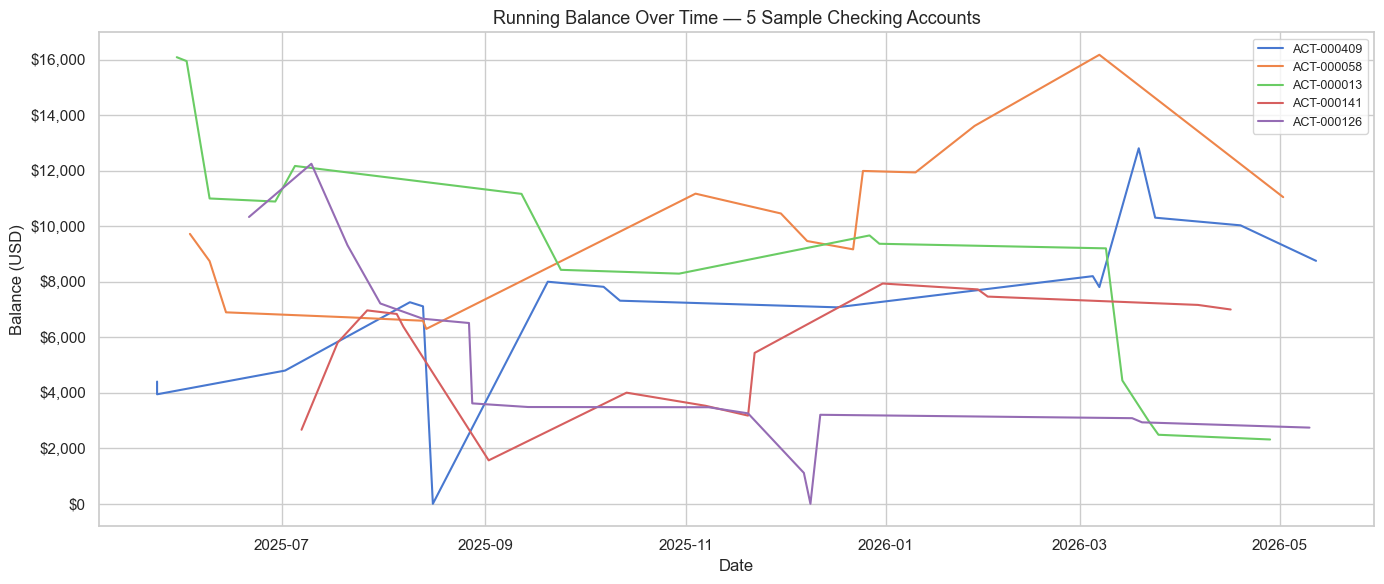

In [11]:
import random
random.seed(SEED)

checking_ids = [a.account_id for a in accounts if a.account_type == AccountType.CHECKING]
sample_ids = random.sample(checking_ids, min(5, len(checking_ids)))

fig, ax = plt.subplots(figsize=(14, 6))

for acct_id, color in zip(sample_ids, sns.color_palette('muted', len(sample_ids))):
    acct_txns = df[df['account_id'] == acct_id].sort_values('post_date')
    ax.plot(acct_txns['post_date'], acct_txns['running_balance'],
            label=acct_id, color=color, linewidth=1.5)

ax.set_title('Running Balance Over Time — 5 Sample Checking Accounts', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Balance (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Export Transaction Data

In [12]:
from src.utils.exporters import write_json, write_csv

output_dir = Path.cwd().parent / 'data' / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

write_json(transactions, output_dir / 'transactions.json')
write_csv(transactions, output_dir / 'transactions.csv')

print(f'Files written to: {output_dir.resolve()}')
print(f'  transactions.json')
print(f'  transactions.csv')

Files written to: /Users/gabrielolson/projects/synthetic-data-creation/data/outputs
  transactions.json
  transactions.csv
